# Calibration and thresholding

This notebook covers **reliability diagrams**, **Platt and isotonic calibration** (`CalibratedClassifierCV`), **Brier score** and **expected calibration error (ECE)**, and a **business cost** view of classification thresholds.

**Data and split** — Same feature matrix and stratified holdout as `02_modelling.ipynb` (`random_state=42`, `test_size=0.2`). The **uncalibrated** pipeline is loaded from `model/model_uncalibrated.pkl` when present (written by `src.train`); otherwise run `uv run python -m src.train` from the repo root first.

In [9]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").is_file() and (p / "src" / "metrics.py").is_file():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml + src/).")


ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT))

from src.metrics import binary_classifier_metrics, format_metrics_lines  # noqa: E402

RANDOM_STATE = 42
TEST_SIZE = 0.2
DB_PATH = ROOT / "data" / "home_credit.db"
MODEL_CANDIDATES = [
    ROOT / "model" / "model_uncalibrated.pkl",
]

In [10]:
import duckdb
from src.features import build_feature_matrix

conn = duckdb.connect(str(DB_PATH))
df = build_feature_matrix(conn)
conn.close()

X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(X_train.shape, X_test.shape, y.mean())

(246008, 224) (61503, 224) 0.08072881945686496


In [11]:
def load_fitted_pipeline(candidates: list[Path]):
    for p in candidates:
        if p.exists():
            pipe = joblib.load(p)
            print(f"Loaded pipeline from {p}")
            return pipe
    raise FileNotFoundError(
        "No saved model found. From repo root run: uv run python -m src.train\n"
        f"Expected one of: {[str(p) for p in candidates]} (see model/model_uncalibrated.pkl)"
    )


base_pipeline = load_fitted_pipeline(MODEL_CANDIDATES)

Loaded pipeline from /Users/b.evans/Documents/ml_development/credit-risk-ml/model/model_uncalibrated.pkl


## Calibration metrics helpers

**ECE** — partition scores into equal-width bins on $[0,1]$, then average $\lvert \text{acc}(\text{bin}) - \text{mean pred}(\text{bin}) \rvert$ weighted by bin size (standard reliability error).

In [12]:
def expected_calibration_error(
    y_true: np.ndarray, y_prob: np.ndarray, *, n_bins: int = 10
) -> float:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=False)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        m = bin_ids == b
        if not np.any(m):
            continue
        conf = float(np.mean(y_prob[m]))
        acc = float(np.mean(y_true[m]))
        w = float(np.sum(m)) / n
        ece += w * abs(acc - conf)
    return ece


def plot_reliability(ax, y_true, y_prob, *, n_bins: int = 10, title: str):
    prob_true, prob_pred = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy="uniform"
    )
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives (actual)")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")

## Raw (uncalibrated) probabilities on the test holdout

Gradient boosted trees optimise discrimination, not calibrated probabilities — high scores are usually **rank-ordered** well but not **frequency-calibrated**.

Brier (raw): 0.17140
ECE (raw, 10 bins): 0.29154
ROC-AUC: 0.7898
Gini (2×AUC − 1): 0.5796
Average precision (PR-AUC): 0.2904
KS statistic: 0.4421


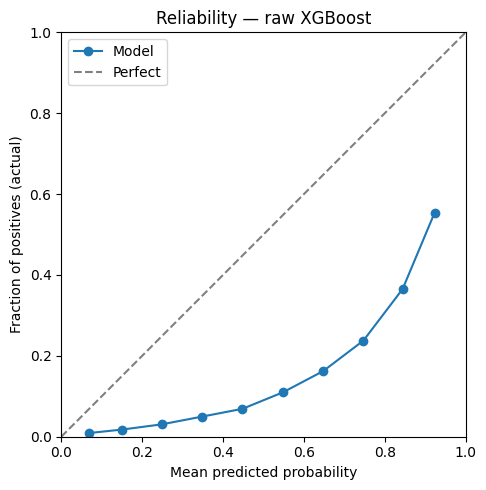

In [13]:
p_raw = base_pipeline.predict_proba(X_test)[:, 1]
brier_raw = brier_score_loss(y_test, p_raw)
ece_raw = expected_calibration_error(y_test.values, p_raw)
print(f"Brier (raw): {brier_raw:.5f}")
print(f"ECE (raw, 10 bins): {ece_raw:.5f}")
print(format_metrics_lines(binary_classifier_metrics(y_test, p_raw)))

fig, ax = plt.subplots(figsize=(5, 5))
plot_reliability(ax, y_test, p_raw, title="Reliability — raw XGBoost")
plt.tight_layout()
plt.show()

## `CalibratedClassifierCV` — Platt (sigmoid) and isotonic

With scikit-learn 1.8+, an already-fitted model is wrapped in **`FrozenEstimator`** so the booster is not retrained. We fit each calibrator on a **calibration slice** of the training split (`train_test_split` on `X_train`), and report metrics on the **held-out test** set. The booster weights were fit on the full training split, so this slice was seen during boosting — a production pipeline would reserve calibration rows **before** fitting the tree model; here we still compare **Platt vs isotonic** and show reliability improvement on the test distribution.

,model,brier,ece_10bin,brier_delta_pct_vs_raw
0,raw,0.171401,0.291540,0.00
1,Platt (sigmoid),0.065820,0.014067,-61.60
2,Isotonic,0.065722,0.012659,-61.66


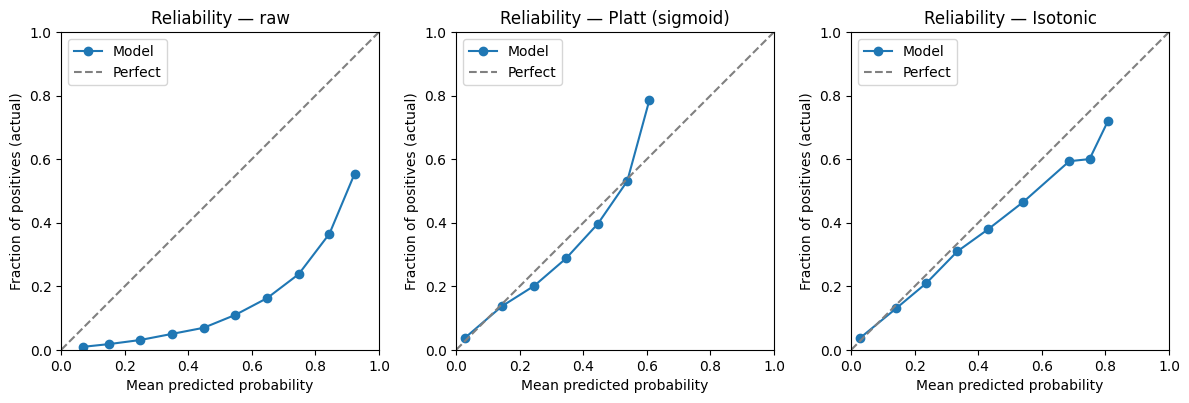

In [14]:
_, X_cal, _, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=7,
    stratify=y_train,
)

cal_sigmoid = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_pipeline), method="sigmoid", cv=3
)
cal_sigmoid.fit(X_cal, y_cal)

cal_isotonic = CalibratedClassifierCV(
    estimator=FrozenEstimator(base_pipeline), method="isotonic", cv=3
)
cal_isotonic.fit(X_cal, y_cal)

p_platt = cal_sigmoid.predict_proba(X_test)[:, 1]
p_iso = cal_isotonic.predict_proba(X_test)[:, 1]

rows = [
    ("raw", p_raw, brier_raw, ece_raw),
    (
        "Platt (sigmoid)",
        p_platt,
        brier_score_loss(y_test, p_platt),
        expected_calibration_error(y_test.values, p_platt),
    ),
    (
        "Isotonic",
        p_iso,
        brier_score_loss(y_test, p_iso),
        expected_calibration_error(y_test.values, p_iso),
    ),
]
summary = pd.DataFrame(
    [(name, br, ece) for name, _, br, ece in rows],
    columns=["model", "brier", "ece_10bin"],
)
summary["brier_delta_pct_vs_raw"] = (
    (summary["brier"] - summary["brier"].iloc[0]) / summary["brier"].iloc[0] * 100
).round(2)
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, p, _, _) in zip(axes, rows):
    plot_reliability(ax, y_test, p, title=f"Reliability — {name}")
plt.tight_layout()
plt.show()

## Threshold optimisation — business cost vs F1

Assume **false negative** (approving a defaulter) costs **5×** a **false positive** (rejecting a good customer). Expected cost per decision at threshold $t$ (treating score as calibrated risk is optional; here we use the **isotonic** probability as a well-behaved risk estimate):

$$\mathbb{E}[\text{cost}] = c_{FP} \cdot FP + c_{FN} \cdot FN$$

Cost-optimal threshold (isotonic p, C_FN/C_FP=5.0/1.0): 0.1676
F1-optimal threshold (isotonic p): 0.1676


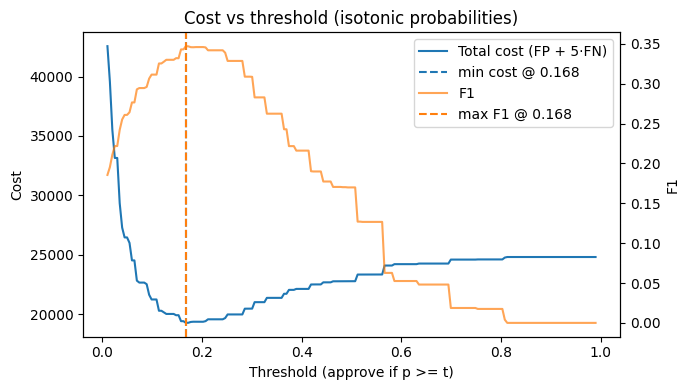

In [15]:
C_FP = 1.0
C_FN = 5.0
y_true_arr = y_test.values.astype(int)


def expected_cost(y_true, y_prob, threshold: float, c_fp: float, c_fn: float) -> float:
    pred = (y_prob >= threshold).astype(int)
    fp = np.sum((pred == 1) & (y_true == 0))
    fn = np.sum((pred == 0) & (y_true == 1))
    return c_fp * fp + c_fn * fn


grid = np.linspace(0.01, 0.99, 200)
costs = [expected_cost(y_true_arr, p_iso, t, C_FP, C_FN) for t in grid]
t_cost_opt = grid[int(np.argmin(costs))]

f1s = [f1_score(y_true_arr, (p_iso >= t).astype(int), zero_division=0) for t in grid]
t_f1_opt = grid[int(np.argmax(f1s))]

print(f"Cost-optimal threshold (isotonic p, C_FN/C_FP={C_FN}/{C_FP}): {t_cost_opt:.4f}")
print(f"F1-optimal threshold (isotonic p): {t_f1_opt:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, costs, label="Total cost (FP + 5·FN)")
ax.axvline(t_cost_opt, color="C0", linestyle="--", label=f"min cost @ {t_cost_opt:.3f}")
ax2 = ax.twinx()
ax2.plot(grid, f1s, color="C1", alpha=0.7, label="F1")
ax2.axvline(t_f1_opt, color="C1", linestyle="--", label=f"max F1 @ {t_f1_opt:.3f}")
ax.set_xlabel("Threshold (approve if p >= t)")
ax.set_ylabel("Cost")
ax2.set_ylabel("F1")
ax.set_title("Cost vs threshold (isotonic probabilities)")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")
plt.tight_layout()
plt.show()

## Fairness check (lightweight)

If **`OCCUPATION_TYPE`** is present in the raw feature frame, we report **ROC-AUC by occupation** (small groups can be noisy). This is a **coarse** slice diagnostic, not a full fairness audit.

In [16]:
from sklearn.metrics import roc_auc_score

if "OCCUPATION_TYPE" in X_test.columns:
    occ = X_test["OCCUPATION_TYPE"].astype(str)
    rows_f = []
    for o in occ.dropna().unique():
        m = occ == o
        if m.sum() < 200 or y_test[m].nunique() < 2:
            continue
        auc_o = roc_auc_score(y_test[m], p_iso[m])
        rows_f.append({"occupation": o, "n": int(m.sum()), "roc_auc": auc_o})
    fair_df = pd.DataFrame(rows_f).sort_values("roc_auc")
    display(fair_df.head(10))
    display(fair_df.tail(10))
else:
    print("OCCUPATION_TYPE not in feature columns — skip group AUC table.")

,occupation,n,roc_auc
9,Cleaning staff,912,0.729231
15,Low-skill Laborers,397,0.729627
11,Waiters/barmen staff,302,0.748090
7,Drivers,3659,0.758473
12,Sales staff,6496,0.764155
3,High skill tech staff,2287,0.772834
10,Private service staff,558,0.773694
1,Security staff,1349,0.775193
5,None,19451,0.779790
14,Accountants,1931,0.780889


,occupation,n,roc_auc
10,Private service staff,558,0.773694
1,Security staff,1349,0.775193
5,None,19451,0.779790
14,Accountants,1931,0.780889
0,Laborers,10927,0.789165
13,Secretaries,258,0.793019
2,Core staff,5477,0.794873
8,Cooking staff,1179,0.797781
4,Managers,4275,0.802567
6,Medicine staff,1666,0.828677
